# Modul 2

> Hands-on 2 IF4021_2024202502
> Created by Doni & Martin<br>
> Reviewed and supervised by Martin Manullang  <br>
> © 2025. Licensed under the MIT License.

## Judul: Working with Images in Python
### Tujuan: Agar praktikan mampu memahami konsep dasar gambar digital dan melakukan manipulasi gambar menggunakan library Python seperti OpenCV dan Matplotlib.

## Pengantar

**Apakah itu Image?**

Gambar pada dasarnya adalah matriks nilai piksel. Setiap piksel mewakili warna, dan intensitas warna tersebut ditentukan oleh nilainya. Umumnya, gambar direpresentasikan dalam 3 channel warna: Merah, Hijau, dan Biru (RGB). Bayangkan saja seperti "microsoft excel" yang memiliki baris dan kolom, gambar juga memiliki baris dan kolom, namun dalam kasus ini, setiap sel memiliki nilai yang mewakili warna.

## Mengimport Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 # opencv
import os

**Penjelasan:**
- `numpy` adalah library yang digunakan untuk operasi matriks
- `matplotlib` adalah library yang digunakan untuk plotting
- `cv2` adalah library `opencv` yang digunakan untuk membaca, menulis, dan memproses gambar
- `os` adalah library yang digunakan untuk berinteraksi dengan sistem operasi

## Gambar adalah Matriks

In [2]:
numpy_img_1ch = np.array([
    [0, 0, 128, 150, 150],
    [0, 0, 128, 150, 150],
    [128, 128, 128, 128, 128],
    [80, 80, 128, 0, 0],
    [80, 80, 128, 0, 0],
], dtype=np.uint8)

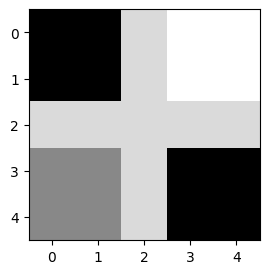

In [3]:
plt.figure(figsize=(3, 3))
plt.imshow(numpy_img_1ch, cmap='gray')
plt.show()

**Pertanyaan analisa:**
- Mengapa kita perlu menuliskan `cmap='gray'` pada `imshow`?
- Apa maksud dari `dtype=np.uint8`?
- Bagaimana jika kita mau membuat tanda '+' berwarna abu-abu?

#### Versi RGB

In [6]:
# Create an RGB version of the numpy_img_1ch with a yellow plus sign and green background
numpy_img_rgb = np.zeros((5, 5, 3), dtype=np.uint8)

# Set the background to green
numpy_img_rgb[:, :] = [0, 255, 0]

# Set the plus sign to yellow
numpy_img_rgb[2, :] = [255, 255, 0]
numpy_img_rgb[:, 2] = [255, 255, 0]

numpy_img_rgb[0, 4] = [0, 0, 255]

print(f"Channel Merah: \n{numpy_img_rgb[:, :, 0]}")
print(f"Channel Hijau: \n{numpy_img_rgb[:, :, 1]}")
print(f"Channel Biru: \n{numpy_img_rgb[:, :, 2]}")

Channel Merah: 
[[  0   0 255   0   0]
 [  0   0 255   0   0]
 [255 255 255 255 255]
 [  0   0 255   0   0]
 [  0   0 255   0   0]]
Channel Hijau: 
[[255 255 255 255   0]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]
Channel Biru: 
[[  0   0   0   0 255]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


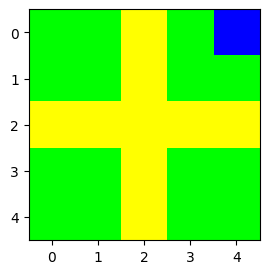

In [7]:
plt.figure(figsize=(3, 3))
plt.imshow(numpy_img_rgb)
plt.show()

**Experimen Mandiri:**

_Jika anda ingin sungguh-sungguh belajar, coba kerjakan pertanyaan berikut walaupun tidak dinilai._
- Coba ubah agar kotak kecil di kanan atas menjadi warna biru

Kesimpulan: Gambar adalah matriks nilai piksel. Setiap piksel mewakili warna, dan intensitas warna tersebut ditentukan oleh nilainya.

---
## Membaca Gambar

In [9]:
path_gambar1 = os.path.join(os.getcwd(), 'data', 'sample-a-img-if4021.jpg')
path_gambar2 = os.path.join(os.getcwd(), 'data', 'sample-b-img-if4021.jpg')

# mengecek apakah file gambar ada
# jika tidak ada, akan tercetak pesan "File tidak ditemukan: <path>"
if not os.path.exists(path_gambar1):
    print('File tidak ditemukan:', path_gambar1)
    exit()

## Cara Memuat Gambar Menggunakan `cv2.imread`

Untuk meloading gambar menggunakan `cv2.imread`, ikuti langkah-langkah berikut:

1. **Import Library yang Diperlukan**: Pastikan Anda telah mengimport library `cv2` dan `os`.

2. **Tentukan Path Gambar**: Tentukan path gambar yang ingin Anda load. Anda bisa menggunakan fungsi `os.path.join` untuk membuat path yang sesuai dengan sistem operasi Anda.
    - *Mengapa menggunakan `os.path.join` lebih baik ketimbang langsung menuliskan path secara manual?*
        - Karena `os.path.join` akan menyesuaikan path sesuai dengan sistem operasi yang digunakan.
        - Akan terjadi masalah apabila kita menggunakan path secara manual pada sistem operasi yang berbeda. Misalnya, tanda pemisah path pada Windows adalah `\` sedangkan pada Linux adalah `/`.
3. **Load Gambar**: Gunakan fungsi `cv2.imread` untuk meload gambar. Fungsi ini akan mengembalikan gambar dalam bentuk array numpy.

4. **Tampilkan Gambar**: Anda bisa menggunakan `cv2.imshow` untuk menampilkan gambar yang telah diload.

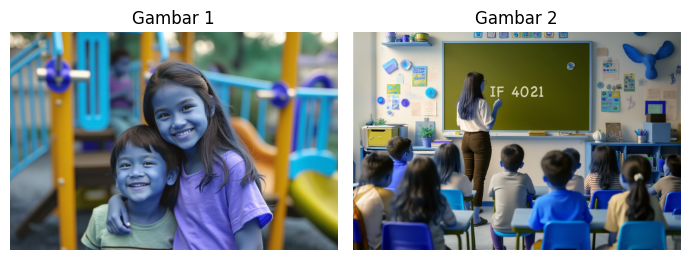

In [10]:
img1 = cv2.imread(path_gambar1)
img2 = cv2.imread(path_gambar2)

ax, fig = plt.subplots(1, 2, figsize=(7, 4))
fig[0].imshow(img1)
fig[0].set_title('Gambar 1')
fig[0].axis('off')
fig[1].imshow(img2)
fig[1].set_title('Gambar 2')
fig[1].axis('off')
plt.tight_layout()
plt.show()

**Penjelasan:**
- Kita menggunakan `ax, fig = plt.subplots(1, 2)` untuk membuat 2 plot sejajar. Ini akan mempermudah dan membuat lebih rapi ketimbang menggunakan 2 plot terpisah. Rumusnya adalah

```python
fig, ax = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(lebar, tinggi))
```

- Dapat kita amati bahwa warna pada gambar tidak sesuai dengan aslinya. Hal ini dikarenakan format channel yang digunakan oleh `cv2.imread` adalah BGR, bukan RGB. Sementara `imshow` menggunakan format RGB.
- `fig[0].axis('off')` dan `fig[1].axis('off')` digunakan untuk menghilangkan sumbu pada plot.

**Mari kita perbaiki urutan channel pada gambar tersebut!**

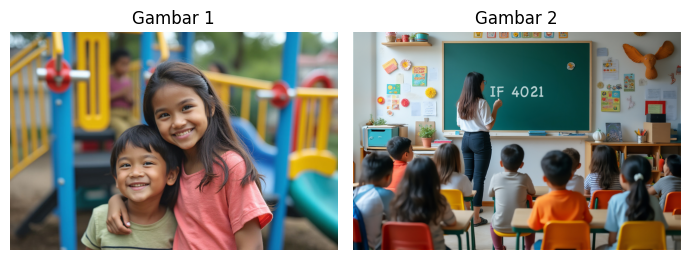

In [11]:
img1 = cv2.imread(path_gambar1) # masih dalam format BGR
img2 = cv2.imread(path_gambar2) # masih dalam format BGR

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # konversi ke format RGB
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) # konversi ke format RGB

ax, fig = plt.subplots(1, 2, figsize=(7, 4))
fig[0].imshow(img1)
fig[0].set_title('Gambar 1')
fig[0].axis('off')
fig[1].imshow(img2)
fig[1].set_title('Gambar 2')
fig[1].axis('off')
plt.tight_layout() # untuk mengatur jarak antar gambar agar lebih rapi
plt.show()

## Bermain dengan Pixel Value

Gambar tersebut tersusun atas nilai-nilai RGB sepanjang baris dan kolom. Nilai RGB tersebut memiliki rentang 0-255.

**Mengapa 0-255?**
- Karena kita bekerja dengan gambar 8-bit. Artinya, setiap channel memiliki 8-bit, sehingga rentang nilai yang mungkin adalah 0-255.
- 8 bit berarti warna hitam adalah `00000000` dan warna putih adalah `11111111` atau 0-255 dalam desimal.

Mari melihat isi dari pixel value tersebut. Pertama-tama kita mau mengecek `shape` dari gambar tersebut. `shape` adalah atribut dari numpy array yang menunjukkan dimensi dari array tersebut.

In [12]:
print(f"Mengecek ukuran dimensi gambar: {img1.shape}")

Mengecek ukuran dimensi gambar: (768, 1152, 3)


Urutan `shape` adalah `(baris, kolom, channel)`. Mari coba kita lihat isi dari pixel value tersebut untuk masing-masing channel R, G, dan B pada 5 baris pertama dan 5 kolom pertama.

In [13]:
row5_column5_img1 = img1[0:5, 0:5]
print(f"Isi dari row5_column5_img1:\n{row5_column5_img1}")

Isi dari row5_column5_img1:
[[[131 139 142]
  [118 133 138]
  [104 132 135]
  [ 95 130 134]
  [ 88 126 129]]

 [[124 134 136]
  [111 129 133]
  [102 130 133]
  [ 95 130 134]
  [ 88 126 129]]

 [[116 132 132]
  [108 128 129]
  [102 130 133]
  [ 97 131 133]
  [ 91 126 128]]

 [[116 136 135]
  [107 131 131]
  [103 133 135]
  [101 132 135]
  [ 94 128 130]]

 [[116 143 138]
  [107 136 132]
  [103 133 133]
  [100 131 133]
  [ 93 124 126]]]


Supaya anda semakin jelas, kita akan mengubah seluruh nilai pixel tersebut (100 row pertama, dan 100 column pertama) menjadi 0 pada channel G dan B serta 255 pada channel R. Dengan demikian, gambar tersebut akan menjadi merah.

Dimensi gambar: (768, 1152, 3)


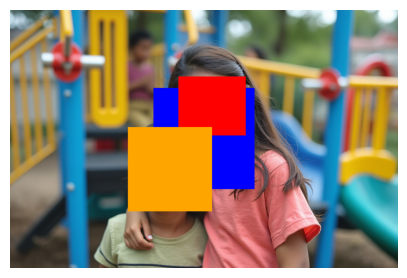

In [15]:
img1 = cv2.imread(path_gambar1) # masih dalam format BGR
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # konversi ke format RGB

merah = [255, 0, 0]
orange = [255, 165, 0]

print(f"Dimensi gambar: {img1.shape}")

height = 300
width = 300

center_y = img1.shape[0] // 2
center_x = img1.shape[1] // 2
blue = [0, 0, 255]
img1[center_y - height // 2:center_y + height // 2, center_x - width // 2:center_x + width // 2] = blue

x, y , w, h = 500, 200, 200, 175
img1[y:y+h, x:x+w] = merah

x1, y1, x2, y2 = 350, 350, 600, 600
img1[y1:y2, x1:x2] = orange

plt.figure(figsize=(5, 5))
plt.imshow(img1)
plt.axis('off')
plt.show()

**Pertanyaan Analisa:**

_Jika anda ingin sungguh-sungguh belajar, coba kerjakan pertanyaan berikut walaupun tidak dinilai._

- Dapatkah anda membuat kotak warna biru di bagian tengah dari gambar 2?
    - Anda dapat menghitung dimensi dari gambar tersebut dengan cara `img.shape`, lalu menghitung nilai tengahnya untuk membantu anda membuat kotak tersebut.

> Pertanyaan analisa adalah pertanyaan yang tidak dinilai. Namun jika anda memang ingin sungguh-sungguh belajar, sangat disarankan untuk mencoba menjawabnya. "Challange yourself!"

## Konversi Menjadi Grayscale

Sekarang, kita akan mencoba mengkonversi gambar tersebut menjadi grayscale. Grayscale adalah gambar yang hanya memiliki 1 channel. Kita akan menggunakan method `cv2.cvtColor` untuk mengkonversi gambar tersebut.

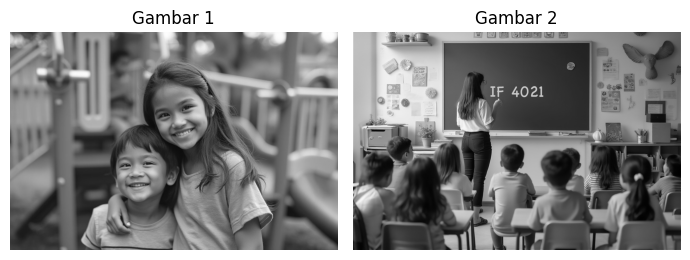

In [13]:
# memuat ulang gambar 1 dan gambar 2
img1 = cv2.imread(path_gambar1) # ingat, gambar yang dimuat masih dalam format BGR
img2 = cv2.imread(path_gambar2)

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) # konversi ke format Grayscale
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY) # konversi ke format Grayscale

ax, fig = plt.subplots(1, 2, figsize=(7, 4))
fig[0].imshow(img1, cmap='gray')
fig[0].set_title('Gambar 1')
fig[0].axis('off')
fig[1].imshow(img2, cmap='gray')
fig[1].set_title('Gambar 2')
fig[1].axis('off')
plt.tight_layout()
plt.show()

## Menampilkan Histogram

Histogram adalah grafik yang menunjukkan distribusi intensitas warna pada gambar. Histogram sangat berguna untuk mengetahui distribusi warna pada gambar. Kita akan menggunakan `cv2.calcHist` untuk menghitung histogram dari gambar tersebut.

**Jangan lupa, image yang kita load belum diubah ke RGB**

In [14]:
img1 = cv2.imread(path_gambar1)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

In [15]:
histo_red = cv2.calcHist([img1], [0], None, [256], [0, 256])
histo_green = cv2.calcHist([img1], [1], None, [256], [0, 256])
histo_blue = cv2.calcHist([img1], [2], None, [256], [0, 256])

Penjelasan **cv2.calcHist**:

```python
cv2.calcHist(images, channels, mask, histSize, ranges)
```

dimana:
- `images` adalah gambar yang akan dihitung histogramnya
- `channels` adalah channel yang akan dihitung histogramnya
- `mask` adalah mask yang akan digunakan. Jika `None`, maka akan menghitung seluruh gambar
- `histSize` adalah jumlah bin yang akan digunakan. Maksudnya adalah, histogram akan dibagi menjadi beberapa bagian sesuai dengan jumlah bin tersebut.
- `ranges` adalah range nilai yang akan digunakan. Biasanya adalah `(0, 256)` untuk gambar 8-bit.

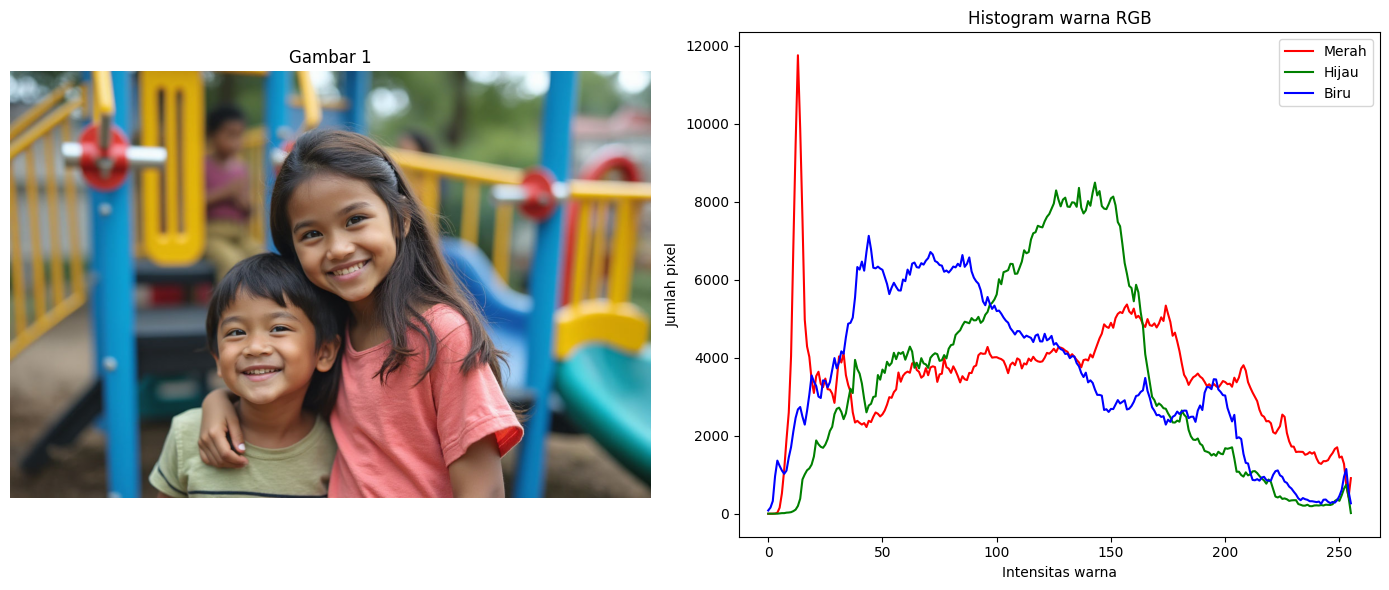

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot the actual image
ax[0].imshow(img1)
ax[0].set_title('Gambar 1')
ax[0].axis('off')

# Plot the histogram
ax[1].plot(histo_red, color='red')
ax[1].plot(histo_green, color='green')
ax[1].plot(histo_blue, color='blue')
ax[1].set_title('Histogram warna RGB')
ax[1].set_xlabel('Intensitas warna')
ax[1].set_ylabel('Jumlah pixel')
ax[1].legend(['Merah', 'Hijau', 'Biru'])

plt.tight_layout()
plt.show()

**Cara Membaca / Menginterpretasi Histogram**
1. Histogram yang tinggi menunjukkan banyaknya piksel pada nilai tersebut.
2. Dalam kasus diatas, channel merah dengan intensitas warna rendah (0-50) memiliki piksel yang lebih banyak dibandingkan dengan channel biru dan hijau. Artinya:
    - Warna merah yang tampil di gambar cenderung lebih gelap.
3. Dalam istilah fotografi, intensitas warna ini dapat dikategorikan sebagai:
    - Black: Intensitas 0 - 50
    - Shadows: Intensitas 50 - 100
    - Midtones: Intensitas 100 - 150
    - Highlights: Intensitas 150 - 200
    - White: Intensitas 200 - 255

**Mari kita coba untuk menaikkan intensitas warna hanya pada channel merah.**

In [17]:
img1_edit = img1.copy() # kita buat salinan dari img1 agar tidak merubah img1 asli
img1_edit[:,:,0] = img1[:,:,0] * 1.2 # Menaikkan semua nilai pixel pada channel merah sebesar 20%

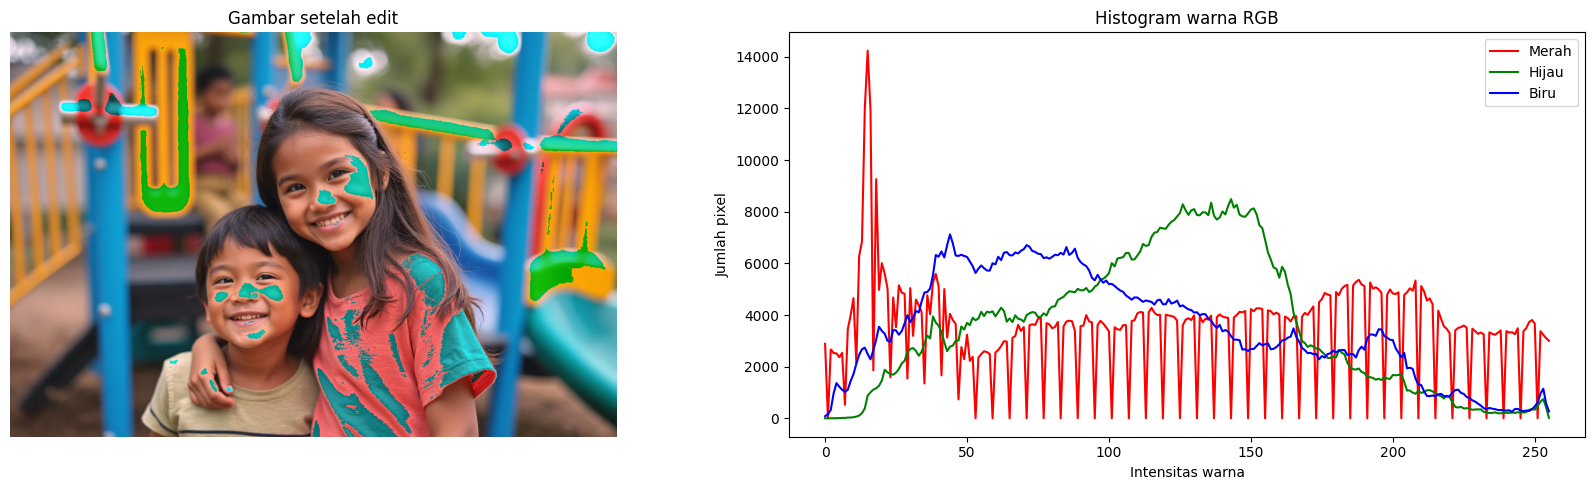

In [18]:
histo_img1_red_edit = cv2.calcHist([img1_edit], [0], None, [256], [0, 256])
histo_img1_green_edit = cv2.calcHist([img1_edit], [1], None, [256], [0, 256])
histo_img1_blue_edit = cv2.calcHist([img1_edit], [2], None, [256], [0, 256])

ax, fig = plt.subplots(1, 2, figsize=(17, 5))
fig[0].imshow(img1_edit)
fig[0].axis('off')
fig[0].set_title('Gambar setelah edit')
fig[1].plot(histo_img1_red_edit, color='red')
fig[1].plot(histo_img1_green_edit, color='green')
fig[1].plot(histo_img1_blue_edit, color='blue')
fig[1].set_title('Histogram warna RGB')
fig[1].set_xlabel('Intensitas warna')
fig[1].set_ylabel('Jumlah pixel')
fig[1].legend(['Merah', 'Hijau', 'Biru'])
plt.tight_layout()
plt.show()

Gambar akan rusak apabila kita mengalikannya secara langsung. Sangat disrankan menggunakan operasi seperti `cv2.add` untuk menambah atau `cv2.multiply` untuk mengalikan.

---

## Menaikkan Intensitas Warna Merah Tanpa Merusak Gambar

- Kita akan menaikkan intensitas warna hanya pada channel merah yang berintensitas kurang dari 100

In [19]:
img1_edit = img1.copy() # kita buat salinan dari img1 agar tidak merubah img1 asli

for row in range(img1_edit.shape[0]):
    for col in range(img1_edit.shape[1]):
        
        if img1_edit[row, col, 0] < 100:
            img1_edit[row, col, 0] = img1_edit[row, col, 0] + 30

**Penjelesan:**
- Kita melakukan for-loop untuk row dan column pada gambar tersebut.

```python
for row in range(img1_edit.shape[0]):
    for col in range(img1_edit.shape[1]):
```

- Sehingga, variabel `row` akan berjalan dari 0 hingga jumlah baris gambar, dan variabel `col` akan berjalan dari 0 hingga jumlah kolom gambar.
- Untuk setiap `row` dan `col` kita akan cek apakah nilai pixel tersebut kurang dari 100 (intensitas warna merah yang berada pada bagian rendah).
- Jika iya, maka kita akan menaikkan intensitas warna tersebut dengan menambahkan dengan nilai tertentu

Mari kita cek hasilnya

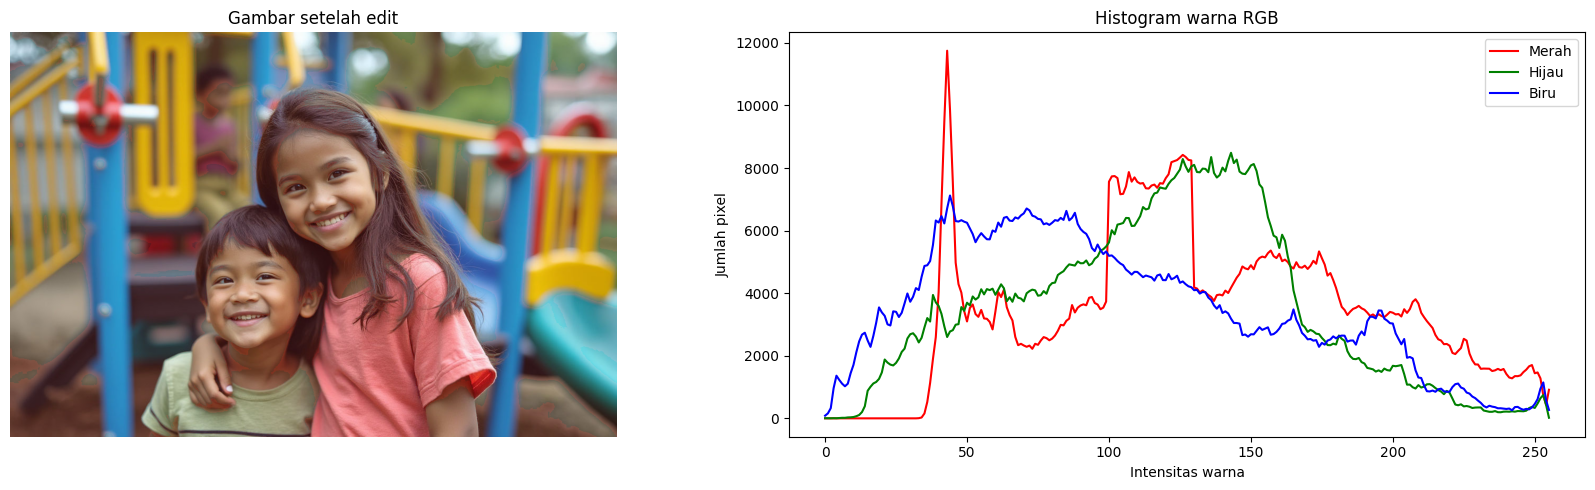

In [20]:
histo_img1_red_edit = cv2.calcHist([img1_edit], [0], None, [256], [0, 256])
histo_img1_green_edit = cv2.calcHist([img1_edit], [1], None, [256], [0, 256])
histo_img1_blue_edit = cv2.calcHist([img1_edit], [2], None, [256], [0, 256])

ax, fig = plt.subplots(1, 2, figsize=(17, 5))
fig[0].imshow(img1_edit)
fig[0].axis('off')
fig[0].set_title('Gambar setelah edit')
fig[1].plot(histo_img1_red_edit, color='red')
fig[1].plot(histo_img1_green_edit, color='green')
fig[1].plot(histo_img1_blue_edit, color='blue')
fig[1].set_title('Histogram warna RGB')
fig[1].set_xlabel('Intensitas warna')
fig[1].set_ylabel('Jumlah pixel')
fig[1].legend(['Merah', 'Hijau', 'Biru'])
plt.tight_layout()
plt.show()

## Operasi Dasar Pada Gambar

Operasi dasar yang sering dilakukan pada gambar meliputi:
- **Resize**: Mengubah ukuran gambar.
- **Crop**: Memotong bagian tertentu dari gambar.
- **Flip**: Membalik gambar secara horizontal atau vertikal.
- **Rotasi**: Memutar gambar dengan sudut tertentu.

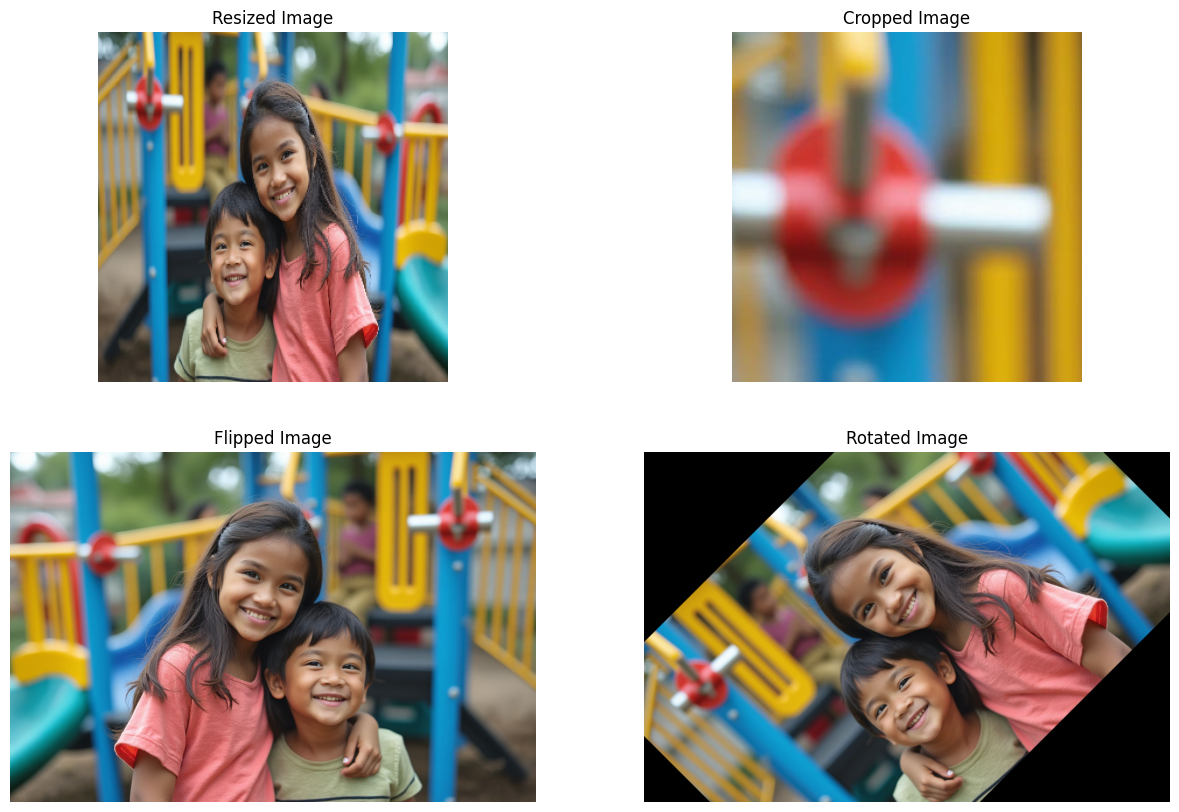

In [21]:
image_rgb = img1.copy()

# Resize
image_resized = cv2.resize(image_rgb, (300, 300))

# Crop
image_cropped = image_rgb[50:250, 100:300]

# Flip
image_flipped = cv2.flip(image_rgb, 1)  # 1 = horizontal flip

# Rotasi
(h, w) = image_rgb.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
image_rotated = cv2.warpAffine(image_rgb, M, (w, h))

# Menampilkan hasil operasi dasar
plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)
plt.imshow(image_resized)
plt.title('Resized Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_cropped)
plt.title('Cropped Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(image_flipped)
plt.title('Flipped Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(image_rotated)
plt.title('Rotated Image')
plt.axis('off')

plt.show()

### 1. Resize (Mengubah Ukuran Gambar)
Resize adalah proses mengubah ukuran gambar ke dimensi yang diinginkan. Ini sering digunakan untuk:
- Mengurangi ukuran file gambar
- Menyesuaikan gambar dengan resolusi layar atau halaman web
- Normalisasi ukuran input untuk model pembelajaran mesin

**Cara Kerja:**
- OpenCV menggunakan fungsi `cv2.resize()` untuk mengubah ukuran gambar.
- Dimensi baru ditentukan dalam bentuk tuple `(width, height)`.
- Metode interpolasi digunakan untuk menghitung nilai piksel baru:
  - `cv2.INTER_LINEAR` (default): Cocok untuk memperbesar gambar.
  - `cv2.INTER_AREA`: Cocok untuk memperkecil gambar.
  - `cv2.INTER_CUBIC` dan `cv2.INTER_LANCZOS4`: Kualitas tinggi untuk memperbesar.


### 2. Crop (Memotong Gambar)
Crop adalah proses memotong bagian tertentu dari gambar, seperti memperbesar objek tertentu atau menghilangkan latar belakang yang tidak diperlukan.

**Cara Kerja:**
- Gambar direpresentasikan sebagai array numpy dengan format `[height, width, channels]`.
- Crop dilakukan dengan slicing array numpy:
  - `cropped_image = image[y1:y2, x1:x2]`
  - `y1`, `y2` adalah batas vertikal, dan `x1`, `x2` adalah batas horizontal.


### 3. Flip (Membalik Gambar)
Flip adalah proses membalik gambar secara horizontal, vertikal, atau keduanya. 

**Cara Kerja:**
- OpenCV menggunakan fungsi `cv2.flip()` dengan parameter arah:
  - `0`: Membalik secara vertikal.
  - `1`: Membalik secara horizontal.
  - `-1`: Membalik secara horizontal dan vertikal.


### 4. Rotasi (Memutar Gambar)
Rotasi adalah proses memutar gambar dengan sudut tertentu, misalnya 90 derajat, 180 derajat, atau sudut bebas.

**Cara Kerja:**
- Rotasi dilakukan menggunakan `cv2.getRotationMatrix2D()` untuk mendapatkan matriks rotasi, dan `cv2.warpAffine()` untuk menerapkan rotasi.
- Parameter yang digunakan:
  - `center`: Titik pusat rotasi (biasanya tengah gambar).
  - `angle`: Sudut rotasi dalam derajat. Positif = searah jarum jam, negatif = berlawanan.
  - `scale`: Skala gambar setelah rotasi.

---

## Tugas: `ho2`

1. Dengan foto anda sendiri, lakukanlah eksperimen berikut ini. Editlah sebuah foto yang terdapat wajah anda, namun kali ini tidak dengan photoshop, melainkan dengan python. Lakukan penyesuaian berikut ini.
    - Lakukan resize untuk foto anda menjadi `1080` pada dimension terpanjangnya. Gunakan `cv2.resize` untuk melakukan resize.
    - Buatlah frame berwarna ungu/magenta (RGB value: 255, 0, 255) sebesar 20 pixel + dua digit terakhir NIM anda pada setiap sisi foto anda. Frame tersebut akan mengelilingi foto setebal 20 pixel + dua digit terakhir NIM anda.
    - Aturlah intensitas warna pada channel merah di bagian tengah (50 - 150), dan naikkan sebesar 3 poin
    - Turunkanlah intensitas warna pada channel biru di atas (200- 250), dan turunkan sebesar 30poin
    - Tampilkanlah histogram dari foto tersebut
    - Jelaskan hasil eksperimen anda

2. Dengan foto anda sendiri, lakukanlah eksperimen berikut ini
    - Convert image dari RGB menjadi Grayscale
    - Tampilkan histogram dari foto tersebut
    - Lakukanlah normalisasi level intensitas warna pada foto tersebut. Aturlah agar intensitas warna terendah menjadi 0, dan intensitas warna tertinggi menjadi 255
    - Tampilkan histogram dari hasil normalisasi
    - Buatlah pixel-art dari foto tersebut. Caranya adalah dengan mengubah intensitas warna menjadi 0 atau 255. Jika intensitas warna < 128, maka ubah menjadi 0, dan jika intensitas warna >= 128, maka ubah menjadi 255. Tunjukkan hasilnya
    - Anda dapat menambahkan kreasi lain selain dari pixel-art, misalnya menambahkan efek blur, menambahkan efek noise, atau menambahkan efek lain yang anda inginkan

3. Dengan foto anda sendiri, lakukanlah eksperimen berikut ini
    - Naikkan kecerahan (brightnes) pada foto tersebut. Anda tidak boleh menggunakan library `cv2` untuk menaikkan kecerahan. Anda hanya boleh menggunakan operasi matriks dengan numpy. Jelaskan langkah-langkah yang anda lakukan. Tampilkan histogram dari foto tersebut
    - Turunkan saturasi warna pada foto tersebut. Anda tidak boleh menggunakan library `cv2` untuk menurunkan saturasi warna. Anda hanya boleh menggunakan operasi matriks dengan numpy. Jelaskan langkah-langkah yang anda lakukan. Tampilkan histogram dari foto tersebut
    - Turunkan kontras pada foto tersebut. Anda tidak boleh menggunakan library `cv2` untuk menurunkan kontras. Anda hanya boleh menggunakan operasi matriks dengan numpy. Jelaskan langkah-langkah yang anda lakukan. Tampilkan histogram dari foto tersebut


### Pengumpulan
- Link pengumpulan ada di web perkuliahan
- Deadline akan diinformasikan di web perkuliahan
- Yang perlu dikumpulkan adalah hasil render .pdf (disarankan kalau berantakan, render via html, lalu buka html di browser dan save as pdf). Juga kumpulkan .ipynb
- Pastikan .ipynb sudah di run dan menampilkan hasil sebelum di save dan diunggah ke submission pengumpulan
- Format penamaan file nim.pdf dan nim.ipynb
- Berikan penjelasan yang sedetail-detailnya untuk setiap bagian eksperimen yang anda lakukan
- Silahkan berdiskusi dengan teman lain, meminta tutor, bertanya pada AI LLM. Namun jangan lupa memberikan atribusi kepada orang yang membantu, sumber yang digunakan, serta transkrip percakapan dengan AI LLM dan attach pada bagian paling bawah dari notebook.

